H0: Las estrategias de inversión hacia cada barrio deben ser distintas, dado que los barrios son distintos entre sí

H1: Es indiferente segmentar por barrio a la hora de invertir, dado que los barrioss son parecidos entre sí 

In [45]:
# ANALIZAMOS COMO VARÍAN LAS DISTINTAS MEDIAS DE VARIABLES MAS RELEVANTES ENTRE LOS DISTINTOS BARRIOS

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


df = pd.read_csv('predicciones_xgboost.csv')

barrio_cols = [
    'Barrio_Almagro','Barrio_Balvanera','Barrio_Belgrano','Barrio_Boedo','Barrio_Caballito',
    'Barrio_Chacarita','Barrio_Constitucion','Barrio_Flores','Barrio_Floresta','Barrio_La Boca',
    'Barrio_Nuñez','Barrio_Palermo','Barrio_Parque Patricios','Barrio_Puerto Madero','Barrio_Recoleta',
    'Barrio_Retiro','Barrio_Saavedra','Barrio_San Nicolás','Barrio_San Telmo','Barrio_Villa Urquiza',
    'Barrio_Villa del Parque'
]

seguridad_cols = [
    'Categoria_Seguridad_Insegura',
    'Categoria_Seguridad_Muy Insegura',
    'Categoria_Seguridad_Muy Segura',
    'Categoria_Seguridad_Segura'
]

df_cat = df.copy()

df_cat['Barrio'] = np.where(
    df_cat[barrio_cols].sum(axis=1) > 0,
    df_cat[barrio_cols].idxmax(axis=1).str.replace('Barrio_', '', regex=False),
    np.nan
)

df_cat['Categoria_Seguridad'] = np.where(
    df_cat[seguridad_cols].sum(axis=1) > 0,
    df_cat[seguridad_cols].idxmax(axis=1).str.replace('Categoria_Seguridad_', '', regex=False),
    np.nan
)

df_cat = df_cat.drop(columns=barrio_cols + seguridad_cols)

df_cat['Barrio'].unique()


df = df_cat.copy()




In [46]:
df['Oportunidad'] = df['Prediccion_Precio'] - df['Precio']
df.to_csv('hipotesis.csv', index = False)

In [47]:
from scipy.stats import f_oneway

variables = ['Precio', 'Expensas', 'Sup_Cubierta_m2', 'Antiguedad']

for var in variables:
    grupos = [
        grupo[var].dropna()
        for _, grupo in df.groupby('Barrio')
        if grupo[var].dropna().shape[0] > 1
    ]
    
    f_stat, p_value = f_oneway(*grupos)
    
    print(f'ANOVA para {var}')
    print(f'F-statistic: {f_stat:.4f}')
    print(f'p-value: {p_value:.6f}')
    
    if p_value < 0.05:
        print('Resultado: se rechaza H0. Hay diferencias significativas entre las medias de los barrios.')
    else:
        print('Resultado: no se rechaza H0. No hay evidencia de diferencias significativas entre las medias de los barrios.')
    
    print('-' * 70)

ANOVA para Precio
F-statistic: 200.6857
p-value: 0.000000
Resultado: se rechaza H0. Hay diferencias significativas entre las medias de los barrios.
----------------------------------------------------------------------
ANOVA para Expensas
F-statistic: 120.8159
p-value: 0.000000
Resultado: se rechaza H0. Hay diferencias significativas entre las medias de los barrios.
----------------------------------------------------------------------
ANOVA para Sup_Cubierta_m2
F-statistic: 28.1849
p-value: 0.000000
Resultado: se rechaza H0. Hay diferencias significativas entre las medias de los barrios.
----------------------------------------------------------------------
ANOVA para Antiguedad
F-statistic: 100.2947
p-value: 0.000000
Resultado: se rechaza H0. Hay diferencias significativas entre las medias de los barrios.
----------------------------------------------------------------------


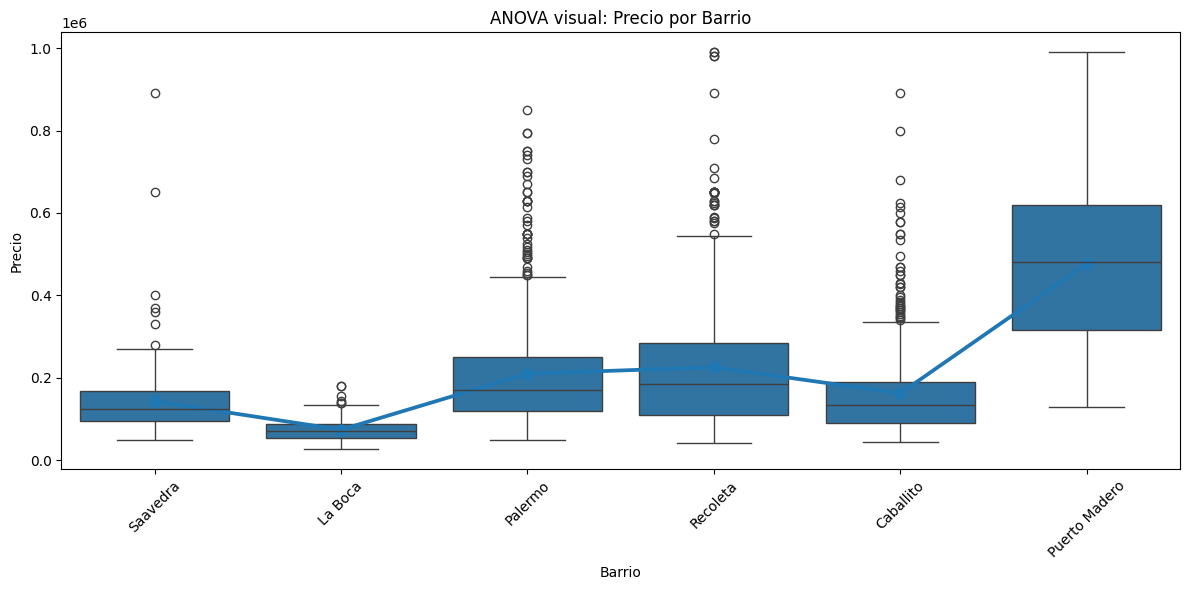

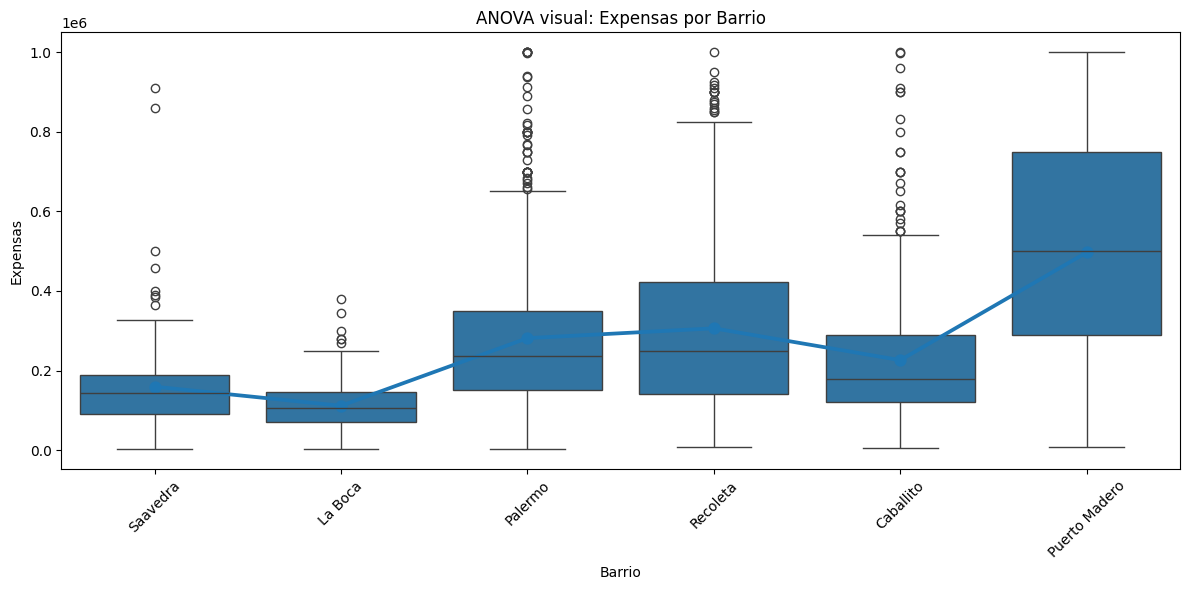

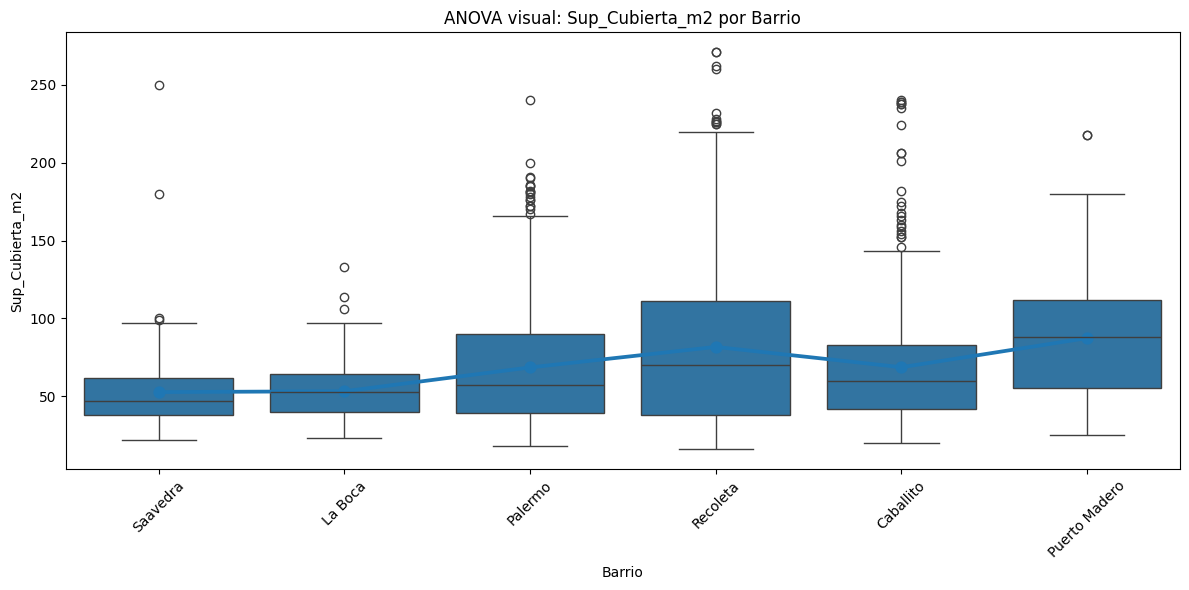

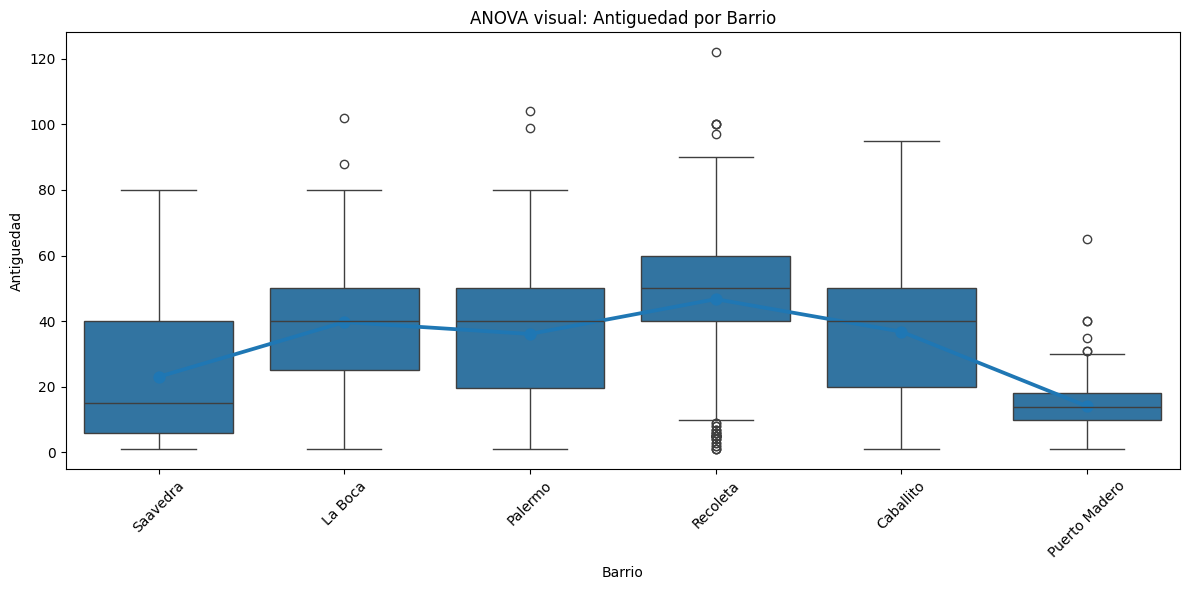

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

variables = ['Precio', 'Expensas', 'Sup_Cubierta_m2', 'Antiguedad']

barrios = [
    'Palermo',
    'Recoleta',
    'Puerto Madero',
    'Caballito',
    'La Boca',
    'Saavedra'
]

df_plot = df[df['Barrio'].isin(barrios)]

for var in variables:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_plot, x='Barrio', y=var)
    sns.pointplot(data=df_plot, x='Barrio', y=var, estimator='mean', errorbar=None)
    plt.title(f'ANOVA visual: {var} por Barrio')
    plt.xlabel('Barrio')
    plt.ylabel(var)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Conclusión: Se rechaza H0 (p < 0,001), indicando que los barrios difieren significativamente en variables clave como precio, expensas, superficie cubierta y antigüedad. Esto respalda la necesidad de diseñar estrategias de inversión específicas para cada barrio. Además, el análisis de PCA muestra una clara separación de las propiedades por barrio, reforzando que la ubicación es un factor determinante en el mercado inmobiliario.

H0: Menos del 50% de las propiedades publicadas se encuentran subvaluadas.

H1: Al menos el 50% de las propiedades publicadas se encuentran subvaluadas.

TEST DE PROPORCIONES (COLA SUPERIOR)
Oportunidades: 4596
Total propiedades: 8514
Proporción observada: 53.9817%
Cota inferior unilateral al 95%: 53.0921%
H0: p <= 50%
H1: p > 50%
Nivel de significancia: 5%
p-value: 0.0000000000
Resultado: se rechaza H0. Hay evidencia de que más del 50% de las propiedades son oportunidades.


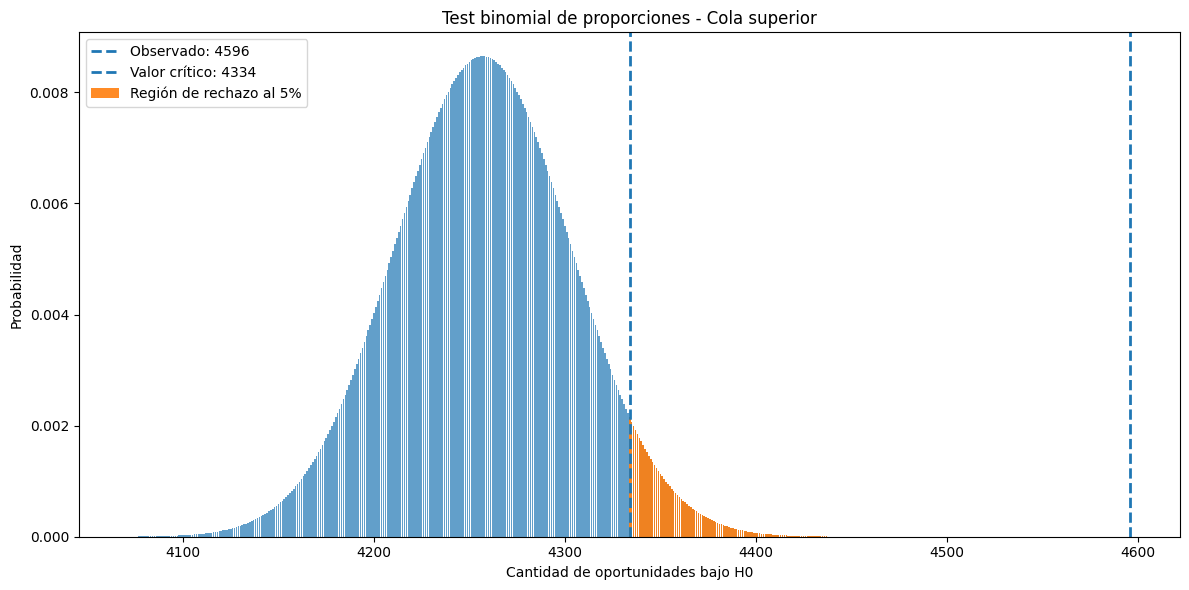

In [49]:
from scipy.stats import binomtest, binom
from statsmodels.stats.proportion import proportion_confint
import numpy as np
import matplotlib.pyplot as plt

p0 = 0.50
alpha = 0.05

x = (df['Oportunidad'] > 0).sum()
n = len(df)
p_obs = x / n

resultado = binomtest(
    k=x,
    n=n,
    p=p0,
    alternative='greater'
)

ci_low, ci_high = proportion_confint(
    count=x,
    nobs=n,
    alpha=2 * alpha,
    method='wilson'
)

print('TEST DE PROPORCIONES (COLA SUPERIOR)')
print(f'Oportunidades: {x}')
print(f'Total propiedades: {n}')
print(f'Proporción observada: {p_obs:.4%}')
print(f'Cota inferior unilateral al 95%: {ci_low:.4%}')

print(f'H0: p <= {p0:.0%}')
print(f'H1: p > {p0:.0%}')
print('Nivel de significancia: 5%')

print(f'p-value: {resultado.pvalue:.10f}')

if resultado.pvalue < alpha:
    print(f'Resultado: se rechaza H0. Hay evidencia de que más del {p0:.0%} de las propiedades son oportunidades.')
else:
    print(f'Resultado: no se rechaza H0. No hay evidencia suficiente para afirmar que más del {p0:.0%} de las propiedades son oportunidades.')

media_h0 = n * p0
std_h0 = np.sqrt(n * p0 * (1 - p0))

x_min = int(max(0, media_h0 - 4 * std_h0))
x_max = int(min(n, media_h0 + 4 * std_h0))

valores = np.arange(x_min, x_max + 1)
probabilidades = binom.pmf(valores, n, p0)

critico = int(binom.ppf(1 - alpha, n, p0)) + 1

plt.figure(figsize=(12, 6))
plt.bar(valores, probabilidades, alpha=0.7)

cola = valores >= critico
plt.bar(valores[cola], probabilidades[cola], alpha=0.9, label='Región de rechazo al 5%')

plt.axvline(x, linestyle='--', linewidth=2, label=f'Observado: {x}')
plt.axvline(critico, linestyle='--', linewidth=2, label=f'Valor crítico: {critico}')

plt.title('Test binomial de proporciones - Cola superior')
plt.xlabel('Cantidad de oportunidades bajo H0')
plt.ylabel('Probabilidad')
plt.legend()
plt.tight_layout()
plt.show()

H0: Como máximo el 3% de las propiedades representan una verdadera oportunidad de compra.

H1: Más del 3% de las propiedades representan una verdadera oportunidad de compra.

TEST DE PROPORCIONES - OPORTUNIDADES FUERTES
RMSE usado como umbral: 39,000
Oportunidades fuertes: 294
Total propiedades: 8514
Proporción observada: 3.4531%
Cota inferior unilateral al 97%: 3.1421%
H0: p <= 3%
H1: p > 3%
Nivel de significancia: 3%
p-value: 0.0087961013
Resultado: se rechaza H0. Hay evidencia de que más del 3% de las propiedades son oportunidades fuertes.


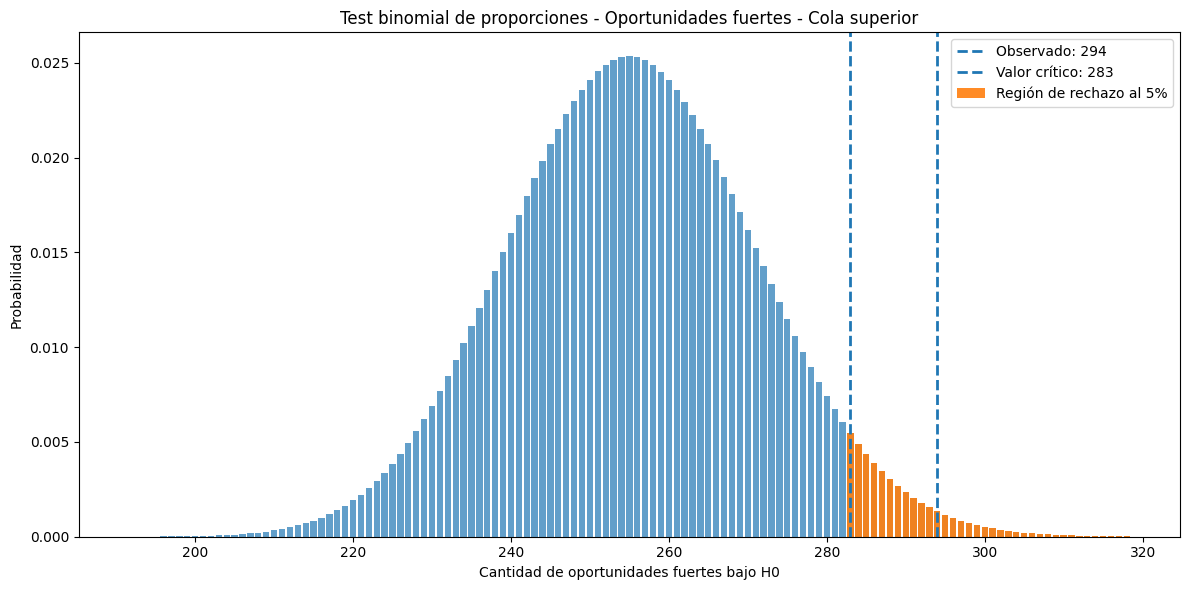

In [50]:
from scipy.stats import binomtest, binom
from statsmodels.stats.proportion import proportion_confint
import numpy as np
import matplotlib.pyplot as plt

rmse = 39000
p0 = 0.03
alpha = 0.05

df['oportunidad_fuerte'] = df['Prediccion_Precio'] - df['Precio'] > rmse

x = df['oportunidad_fuerte'].sum()
n = len(df)
p_obs = x / n

resultado = binomtest(
    k=x,
    n=n,
    p=p0,
    alternative='greater'
)

ci_low, ci_high = proportion_confint(
    count=x,
    nobs=n,
    alpha=2 * alpha,
    method='wilson'
)

print('TEST DE PROPORCIONES - OPORTUNIDADES FUERTES')
print(f'RMSE usado como umbral: {rmse:,.0f}')
print(f'Oportunidades fuertes: {x}')
print(f'Total propiedades: {n}')
print(f'Proporción observada: {p_obs:.4%}')
print(f'Cota inferior unilateral al 97%: {ci_low:.4%}')

print(f'H0: p <= {p0:.0%}')
print(f'H1: p > {p0:.0%}')
print('Nivel de significancia: 3%')

print(f'p-value: {resultado.pvalue:.10f}')

if resultado.pvalue < alpha:
    print(f'Resultado: se rechaza H0. Hay evidencia de que más del {p0:.0%} de las propiedades son oportunidades fuertes.')
else:
    print(f'Resultado: no se rechaza H0. No hay evidencia suficiente para afirmar que más del {p0:.0%} de las propiedades son oportunidades fuertes.')

media_h0 = n * p0
std_h0 = np.sqrt(n * p0 * (1 - p0))

x_min = int(max(0, media_h0 - 4 * std_h0))
x_max = int(min(n, media_h0 + 4 * std_h0))

valores = np.arange(x_min, x_max + 1)
probabilidades = binom.pmf(valores, n, p0)

critico = int(binom.ppf(1 - alpha, n, p0)) + 1

plt.figure(figsize=(12, 6))
plt.bar(valores, probabilidades, alpha=0.7)

cola = valores >= critico
plt.bar(valores[cola], probabilidades[cola], alpha=0.9, label='Región de rechazo al 5%')

plt.axvline(x, linestyle='--', linewidth=2, label=f'Observado: {x}')
plt.axvline(critico, linestyle='--', linewidth=2, label=f'Valor crítico: {critico}')

plt.title('Test binomial de proporciones - Oportunidades fuertes - Cola superior')
plt.xlabel('Cantidad de oportunidades fuertes bajo H0')
plt.ylabel('Probabilidad')
plt.legend()
plt.tight_layout()
plt.show()

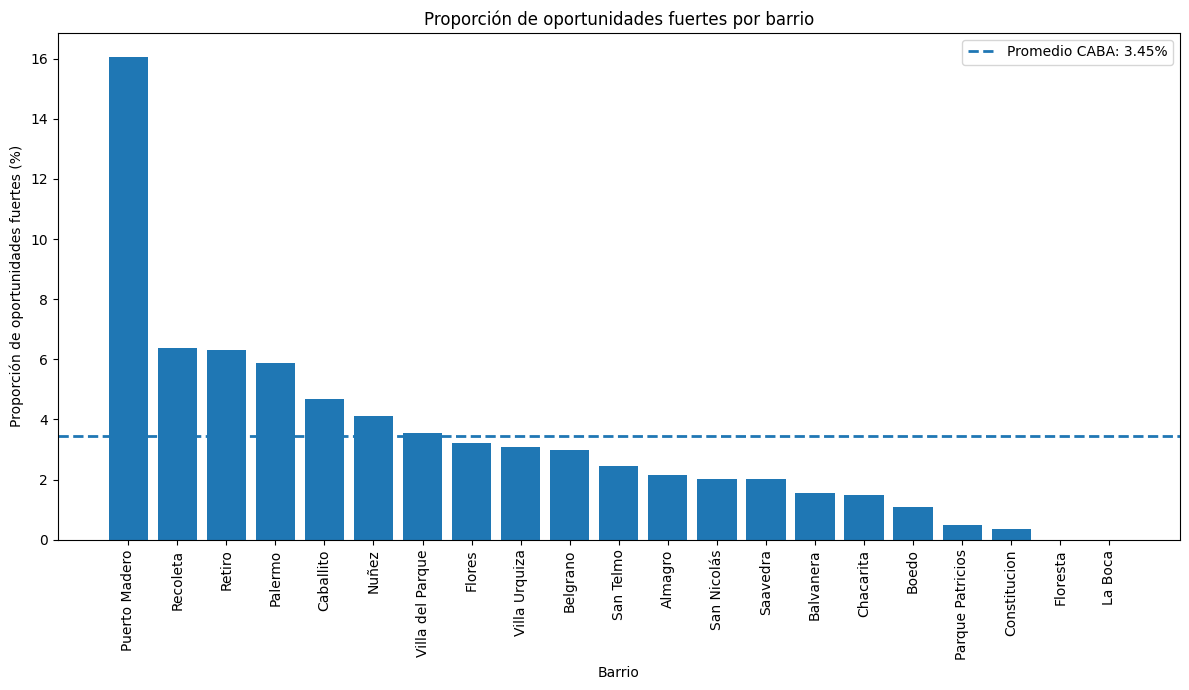

In [51]:
import matplotlib.pyplot as plt

rmse = 39000

df['oportunidad_fuerte'] = df['Prediccion_Precio'] - df['Precio'] > rmse

proporcion_oportunidades_barrio = (
    df.groupby('Barrio')
    .agg(
        total_propiedades=('oportunidad_fuerte', 'count'),
        oportunidades_fuertes=('oportunidad_fuerte', 'sum'),
        proporcion_oportunidades=('oportunidad_fuerte', 'mean')
    )
    .sort_values('proporcion_oportunidades', ascending=False)
)

proporcion_oportunidades_barrio['proporcion_oportunidades'] *= 100

promedio_caba = df['oportunidad_fuerte'].mean() * 100

plt.figure(figsize=(12, 7))
plt.bar(
    proporcion_oportunidades_barrio.index,
    proporcion_oportunidades_barrio['proporcion_oportunidades']
)

plt.axhline(
    promedio_caba,
    linestyle='--',
    linewidth=2,
    label=f'Promedio CABA: {promedio_caba:.2f}%'
)

plt.title('Proporción de oportunidades fuertes por barrio')
plt.xlabel('Barrio')
plt.ylabel('Proporción de oportunidades fuertes (%)')
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

H0: La proporción de oportunidades fuertes entre propiedades antiguas es igual o menor que entre propiedades nuevas.

H1: La proporción de oportunidades fuertes entre propiedades antiguas es mayor que entre propiedades nuevas.

In [52]:
import pandas as pd

rmse = 39000

df['oportunidad_fuerte'] = (df['Prediccion_Precio'] - df['Precio']) > rmse

bins = [-1, 5, 10, 20, 30, 50, 1000]
labels = ['0-5', '6-10', '11-20', '21-30', '31-50', '50+']

df['Rango_Antiguedad'] = pd.cut(
    df['Antiguedad'],
    bins=bins,
    labels=labels
)

resultado = (
    df.groupby('Rango_Antiguedad')
    .agg(
        total_propiedades=('oportunidad_fuerte', 'count'),
        oportunidades_fuertes=('oportunidad_fuerte', 'sum'),
        proporcion_oportunidades=('oportunidad_fuerte', 'mean')
    )
)

resultado['proporcion_oportunidades'] *= 100

print('PROPORCIÓN DE PROPIEDADES SUBVALUADAS POR RANGO DE ANTIGÜEDAD')
print(f'RMSE usado como umbral: {rmse:,.0f}')
print(resultado)

PROPORCIÓN DE PROPIEDADES SUBVALUADAS POR RANGO DE ANTIGÜEDAD
RMSE usado como umbral: 39,000
                  total_propiedades  oportunidades_fuertes  \
Rango_Antiguedad                                             
0-5                             625                     28   
6-10                            640                     32   
11-20                           983                     52   
21-30                           593                     22   
31-50                          3505                     97   
50+                            2168                     63   

                  proporcion_oportunidades  
Rango_Antiguedad                            
0-5                               4.480000  
6-10                              5.000000  
11-20                             5.289929  
21-30                             3.709949  
31-50                             2.767475  
50+                               2.905904  


C:\Users\simon\AppData\Local\Temp\ipykernel_27336\2347523533.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Rango_Antiguedad')


TEST DE PROPORCIONES - PROPIEDADES ANTIGUAS VS NUEVAS
RMSE usado como umbral: 39,000
Propiedades antiguas: 6552
Oportunidades fuertes antiguas: 193
Proporción antiguas: 2.9457%
Propiedades nuevas: 1962
Oportunidades fuertes nuevas: 101
Proporción nuevas: 5.1478%
Diferencia observada: -2.2021%
H0: p_antiguas <= p_nuevas
H1: p_antiguas > p_nuevas
Nivel de significancia: 5%
Estadístico Z: -4.6864
p-value: 0.9999986097
Resultado: no se rechaza H0. No hay evidencia suficiente para afirmar que la proporción de propiedades subvaluadas sea mayor entre las propiedades antiguas.


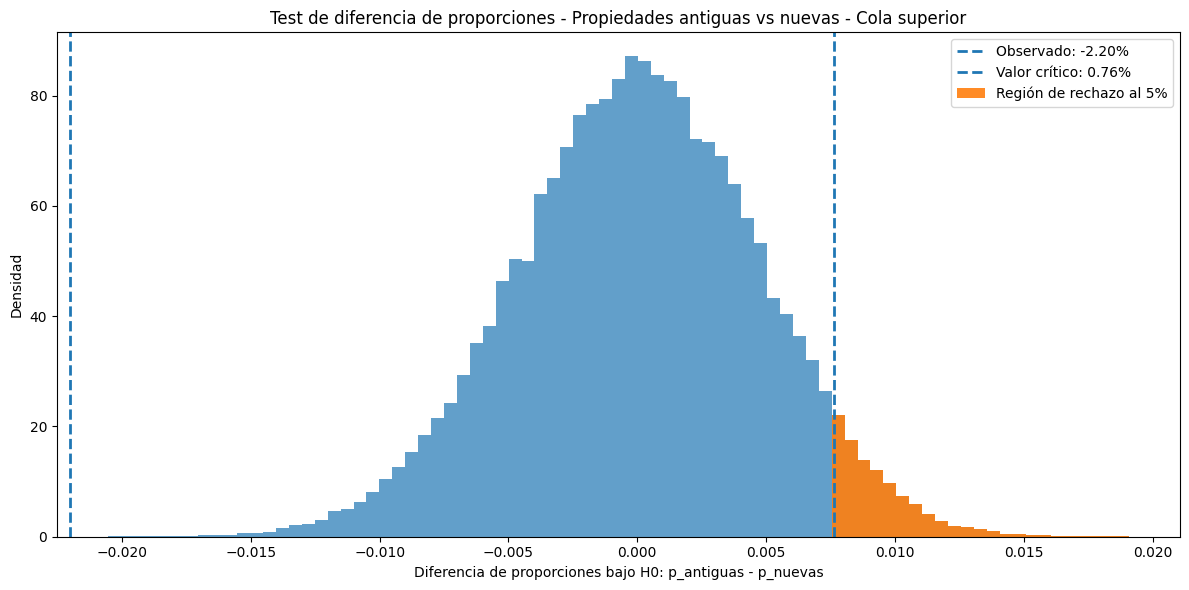

In [53]:
from statsmodels.stats.proportion import proportions_ztest
import numpy as np
import matplotlib.pyplot as plt

rmse = 39000
alpha = 0.05
simulaciones = 100000

df['oportunidad_fuerte'] = df['Prediccion_Precio'] - df['Precio'] > rmse

df['tipo_antiguedad'] = df['Antiguedad'].apply(
    lambda x: 'Nueva' if x < 20 else 'Antigua'
)

x_antiguas = df[df['tipo_antiguedad'] == 'Antigua']['oportunidad_fuerte'].sum()
n_antiguas = df[df['tipo_antiguedad'] == 'Antigua']['oportunidad_fuerte'].count()

x_nuevas = df[df['tipo_antiguedad'] == 'Nueva']['oportunidad_fuerte'].sum()
n_nuevas = df[df['tipo_antiguedad'] == 'Nueva']['oportunidad_fuerte'].count()

p_antiguas = x_antiguas / n_antiguas
p_nuevas = x_nuevas / n_nuevas
diferencia_obs = p_antiguas - p_nuevas

stat, p_value = proportions_ztest(
    count=[x_antiguas, x_nuevas],
    nobs=[n_antiguas, n_nuevas],
    alternative='larger'
)

print('TEST DE PROPORCIONES - PROPIEDADES ANTIGUAS VS NUEVAS')
print(f'RMSE usado como umbral: {rmse:,.0f}')
print(f'Propiedades antiguas: {n_antiguas}')
print(f'Oportunidades fuertes antiguas: {x_antiguas}')
print(f'Proporción antiguas: {p_antiguas:.4%}')
print(f'Propiedades nuevas: {n_nuevas}')
print(f'Oportunidades fuertes nuevas: {x_nuevas}')
print(f'Proporción nuevas: {p_nuevas:.4%}')
print(f'Diferencia observada: {diferencia_obs:.4%}')

print('H0: p_antiguas <= p_nuevas')
print('H1: p_antiguas > p_nuevas')
print('Nivel de significancia: 5%')

print(f'Estadístico Z: {stat:.4f}')
print(f'p-value: {p_value:.10f}')

if p_value < alpha:
    print('Resultado: se rechaza H0. Hay evidencia de que la proporción de propiedades subvaluadas es mayor entre las propiedades antiguas.')
else:
    print('Resultado: no se rechaza H0. No hay evidencia suficiente para afirmar que la proporción de propiedades subvaluadas sea mayor entre las propiedades antiguas.')

p_pool = (x_antiguas + x_nuevas) / (n_antiguas + n_nuevas)

sim_antiguas = np.random.binomial(n_antiguas, p_pool, simulaciones) / n_antiguas
sim_nuevas = np.random.binomial(n_nuevas, p_pool, simulaciones) / n_nuevas
diferencias_h0 = sim_antiguas - sim_nuevas

critico = np.quantile(diferencias_h0, 1 - alpha)

bins = np.linspace(
    diferencias_h0.min(),
    diferencias_h0.max(),
    80
)

conteos, bordes = np.histogram(diferencias_h0, bins=bins, density=True)
centros = (bordes[:-1] + bordes[1:]) / 2
anchos = np.diff(bordes)

plt.figure(figsize=(12, 6))

plt.bar(
    centros,
    conteos,
    width=anchos,
    alpha=0.7,
    align='center'
)

cola = centros >= critico

plt.bar(
    centros[cola],
    conteos[cola],
    width=anchos[cola],
    alpha=0.9,
    align='center',
    label='Región de rechazo al 5%'
)

plt.axvline(
    diferencia_obs,
    linestyle='--',
    linewidth=2,
    label=f'Observado: {diferencia_obs:.2%}'
)

plt.axvline(
    critico,
    linestyle='--',
    linewidth=2,
    label=f'Valor crítico: {critico:.2%}'
)

plt.title('Test de diferencia de proporciones - Propiedades antiguas vs nuevas - Cola superior')
plt.xlabel('Diferencia de proporciones bajo H0: p_antiguas - p_nuevas')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()